## **ENDUTIH 2022.**

### **MATERIA: ESTADÍSTICA.**

Profesora: Claudia García Blanquel.

Alumno:
- Hernández Martínez Pablo.
- Reyes Calva Angel David.

Grupo: 4AM1.

### **1. Importación de Librerías.**

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

### **2. Carga de datos con factor de expansión (FAC_PER)**

In [4]:
# Cargar el archivo completo
df_orig = pd.read_excel("tr_endutih_usuarios2_anual_2022_mod.xlsx", sheet_name=0, engine='openpyxl')

# Columnas a estudiar, ahora incluyendo FAC_PER
cols_w = ["EDAD", "P8_4_2", "SEXO", "ENT", "FAC_PER"]

# Eliminar nulos
df_clean_w = df_orig.dropna(subset=cols_w)

# Filtrar los mismos estados (7, 12, 20)
estados = [7, 12, 20]

# Filtrar solo registros con los estados mencionados
df_filt_w = df_clean_w[df_clean_w['ENT'].isin(estados)].copy()

### **3. Mismo muestro con factor de expansión.**

In [5]:
# Muestreo estratificado usando la misma lógica
muestras_est_w = []
for estado in estados:
    df_est = df_filt_w[df_filt_w['ENT'] == estado] # Filtrar por estado
    n_muestra = min(100, len(df_est))
    muestra = df_est.sample(n=n_muestra, random_state=42) # Muestra aleatoria
    muestras_est_w.append(muestra)

# Unir y conservar las columnas excepto ENT
muestra_300_w = pd.concat(muestras_est_w, ignore_index=True)
muestra_300_w = muestra_300_w[["EDAD", "P8_4_2", "SEXO", "FAC_PER"]].copy()
print(f"Muestra ponderada cargada: {len(muestra_300_w)} registros")

Muestra ponderada cargada: 300 registros


### **4. Estimación poblacional de la proporción de smartphone**


ESTIMACIONES POBLACIONALES (USANDO FACTOR DE EXPANSIÓN)
------------------------------------------------------------
Proporción ponderada de smartphone : 0.9009
Error estándar                     : 0.0188
IC 95% poblacional                 : [0.8641, 0.9377]
Proporción muestral (sin ponderar) : 0.8833

Comparación:
La estimación poblacional difiere en 0.0176 respecto a la muestra sin expandir.
La diferencia está dentro del margen de error muestral.


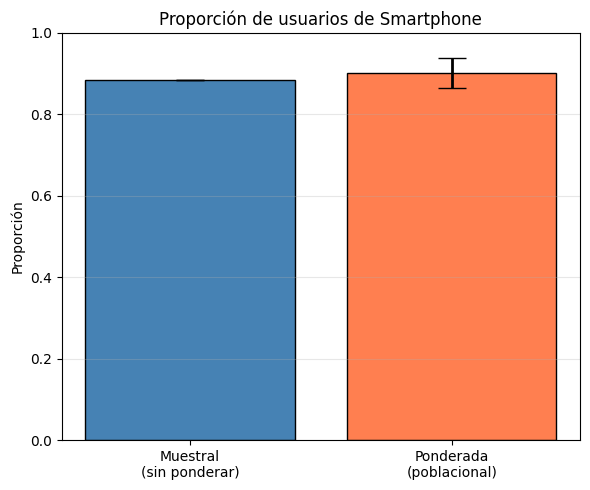

In [6]:
# Convertir P8_4_2 a binario: 1 = Smartphone, 0 = Básico
muestra_300_w['smart'] = (muestra_300_w['P8_4_2'] == 1).astype(int)
w = muestra_300_w['FAC_PER'].values
x = muestra_300_w['smart'].values

# Proporción ponderada
p_hat = np.average(x, weights=w)

# Error estándar ponderado
sum_w = np.sum(w)
se_p = np.sqrt(np.sum(w**2 * (x - p_hat)**2)) / sum_w

# Intervalo de confianza del 95%
z = norm.ppf(0.975)
ic_inf_p = p_hat - z * se_p
ic_sup_p = p_hat + z * se_p

# Proporción muestral sin ponderar
p_muestral = x.mean()

# Imprimir resultados
print("\nESTIMACIONES POBLACIONALES (USANDO FACTOR DE EXPANSIÓN)")
print("-" * 60)
print(f"Proporción ponderada de smartphone : {p_hat:.4f}")
print(f"Error estándar                     : {se_p:.4f}")
print(f"IC 95% poblacional                 : [{ic_inf_p:.4f}, {ic_sup_p:.4f}]")
print(f"Proporción muestral (sin ponderar) : {p_muestral:.4f}")

# Comparacion de si la proporcion sin ponderar esta dentro del IC de la proporcion ponderada
print("\nComparación:")
print(f"La estimación poblacional difiere en {abs(p_hat - p_muestral):.4f} respecto a la muestra sin expandir.")
if ic_inf_p > p_muestral or ic_sup_p < p_muestral:
    print("La diferencia es relevante: el IC poblacional no contiene el valor muestral.")
else:
    print("La diferencia está dentro del margen de error muestral.")

# Datos para el gráfico
categorias = ['Muestral\n(sin ponderar)', 'Ponderada\n(poblacional)']
valores = [p_muestral, p_hat]
# Error solo para la ponderada (la muestral es un valor puntual sin IC)
errores = [0, z * se_p]

# Configuracion del grafico
plt.figure(figsize=(6, 5))
barras = plt.bar(categorias, valores, color=['steelblue', 'coral'], edgecolor='black')
plt.errorbar(categorias, valores, yerr=errores, fmt='none', capsize=10, color='black', linewidth=2)
plt.title('Proporción de usuarios de Smartphone', fontsize=12)
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **5.  Estimaciones poblacionales por sexo**


ESTIMACIONES POR SEXO
------------------------------------------------------------
Hombres:
  Proporción ponderada: 0.8903
  IC 95%: [0.8312, 0.9494]
Mujeres:
  Proporción ponderada: 0.9103
  IC 95%: [0.8650, 0.9556]

COMPARACIÓN ENTRE HOMBRES Y MUJERES
----------------------------------------
Los intervalos de confianza se solapan ampliamente.
No se detecta una diferencia significativa en el uso de smartphone entre sexos.


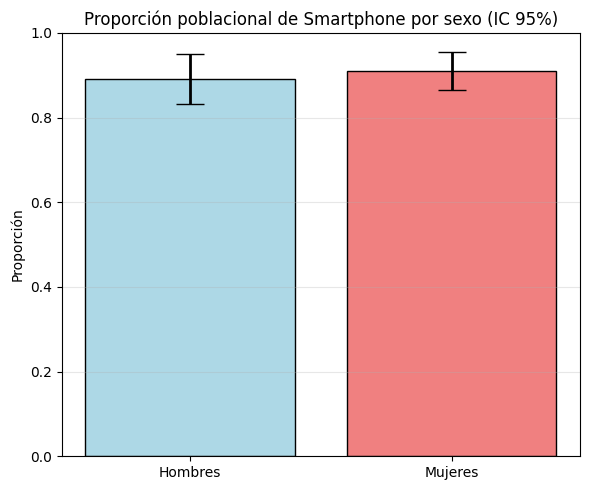

In [7]:
### **5.  Estimaciones poblacionales por sexo**

print("\nESTIMACIONES POR SEXO")
print("-" * 60)

# Listas para guardar las proporciones y errores estándar de cada sexo
sexos = ['Hombres', 'Mujeres']
prop_sex = []      # Proporciones ponderadas
ic_errores = []    # z * error estándar (para el gráfico)

# Recorro cada sexo: 1 = Hombre, 2 = Mujer
for sexo, etiqueta in [(1, 'Hombres'), (2, 'Mujeres')]:
    # Filtro las filas que corresponden a este sexo
    mask = muestra_300_w['SEXO'] == sexo
    w_sex = w[mask]    # Pesos (factor de expansión) para este sexo
    x_sex = x[mask]    # Indicadora de smartphone (0 o 1) para este sexo

    # Calculo la proporción ponderada usando los pesos
    p_sex = np.average(x_sex, weights=w_sex)

    # Error estándar de la proporción ponderada
    se_sex = np.sqrt(np.sum(w_sex**2 * (x_sex - p_sex)**2)) / np.sum(w_sex)

    # Intervalo de confianza del 95 %
    ic_inf_sex = p_sex - z * se_sex
    ic_sup_sex = p_sex + z * se_sex

    # Guardo los resultados para el gráfico
    prop_sex.append(p_sex)
    ic_errores.append(z * se_sex)

    # Imprimo los resultados de este sexo
    print(f"{etiqueta}:")
    print(f"  Proporción ponderada: {p_sex:.4f}")
    print(f"  IC 95%: [{ic_inf_sex:.4f}, {ic_sup_sex:.4f}]")

# --- Interpretación de la diferencia entre sexos ---
print("\nCOMPARACIÓN ENTRE HOMBRES Y MUJERES")
print("-" * 40)

# Calculo los límites de los intervalos
ic_inf_h = prop_sex[0] - ic_errores[0]
ic_sup_h = prop_sex[0] + ic_errores[0]
ic_inf_m = prop_sex[1] - ic_errores[1]
ic_sup_m = prop_sex[1] + ic_errores[1]

# Verifico si los intervalos se solapan
if (ic_inf_h > ic_sup_m) or (ic_inf_m > ic_sup_h):
    print("Los intervalos de confianza no se solapan.")
    print("Esto indica una diferencia estadísticamente significativa entre hombres y mujeres a nivel poblacional.")
else:
    print("Los intervalos de confianza se solapan ampliamente.")
    print("No se detecta una diferencia significativa en el uso de smartphone entre sexos.")

# --- Gráfico de proporciones por sexo con IC ---
plt.figure(figsize=(6, 5))
barras = plt.bar(sexos, prop_sex, color=['lightblue', 'lightcoral'], edgecolor='black')
plt.errorbar(sexos, prop_sex, yerr=ic_errores, fmt='none', capsize=10, color='black', linewidth=2)
plt.title('Proporción poblacional de Smartphone por sexo (IC 95%)', fontsize=12)
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()